# ECS701P Coursework: Music Genre Classification & Instrument Recognition

Name: Shaik Sadaf Patel


Student ID	250784103


**Tasks:**
1. Train two individual deep learning models:
   - **GenreCNN** — CNN on log-mel spectrograms (GTZAN, 10 genres)
   - **InstrumentCRNN** — CRNN on log-mel spectrograms (IRMAS, 11 instruments)
2. Evaluate each model in isolation on held-out test data
3. Explore three fusion strategies to combine both tasks:
   - Late Fusion (concatenated embeddings)
   - Early Fusion (shared backbone)
   - MTL with Cross-Task Attention
4. Qualitative case study on a selected audio file

**Datasets:**
- GTZAN: 1000 clips × 10 genres × 30 s  
  Download: http://marsyas.info/downloads/datasets.html
- IRMAS: ~6700 clips × 11 instruments × 3 s  
  Download: https://www.upf.edu/web/mtg/irmas

**Report word count target:** ~2000 words

## 0. Setup

In [1]:
import subprocess
subprocess.run(['pip', 'install', 'soundfile', '--upgrade'])

CompletedProcess(args=['pip', 'install', 'soundfile', '--upgrade'], returncode=0)

In [2]:
%pip install torch torchvision torchaudio
!pip install librosa


Note: you may need to restart the kernel to use updated packages.


In [3]:
import soundfile as sf
import librosa

# Force librosa to use soundfile backend
def load_audio_fixed(filepath, sr=22050, duration=None):
    y, sr_native = sf.read(filepath, dtype='float32', always_2d=False)
    import numpy as np
    if y.ndim > 1:
        y = np.mean(y, axis=1)  # stereo to mono
    if sr_native != sr:
        y = librosa.resample(y, orig_sr=sr_native, target_sr=sr)
    if duration:
        y = y[:int(duration * sr)]
    return y, sr

In [4]:
import os

GTZAN_ROOT = r"C:\Users\Shaik Sadaf Patel\Downloads\music_project_final\music_project_final\music_project\data\gtzan\genres_original"
IRMAS_ROOT = r"C:\Users\Shaik Sadaf Patel\Downloads\music_project_final\music_project_final\music_project\data\IRMAS-TrainingData"

print("GTZAN exists:", os.path.exists(GTZAN_ROOT))
print("IRMAS exists:", os.path.exists(IRMAS_ROOT))
print("GTZAN folders:", os.listdir(GTZAN_ROOT))
print("IRMAS folders:", os.listdir(IRMAS_ROOT))

GTZAN exists: True
IRMAS exists: True
GTZAN folders: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
IRMAS folders: ['cel', 'cla', 'flu', 'gac', 'gel', 'org', 'pia', 'README.txt', 'sax', 'tru', 'vio', 'voi']


In [5]:
import sys
import os

# This adds the folder one level up (music_project) to Python's search list
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

# Now Python thinks it's in the music_project folder
print(f"Current working directory: {os.getcwd()}")

Current working directory: C:\Users\Shaik Sadaf Patel\Downloads\music_project_final\music_project_final\music_project


In [6]:
# Install dependencies (run once)
# !pip install torch torchaudio librosa scikit-learn matplotlib seaborn

import os, sys, json, random
import numpy as np
import torch

# Add project root to path
sys.path.insert(0, os.path.abspath('.'))

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# ── Set your dataset paths here ──────────────────────────────────────────────
GTZAN_ROOT = 'data/gtzan/genres_original'   # adjust to your download location
IRMAS_ROOT = 'data/irmas/IRMAS-TrainingData' # adjust to your download location
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

Using device: cpu


## 1. Data Loading & Preprocessing

In [7]:
import os

GTZAN_ROOT = r"C:\Users\Shaik Sadaf Patel\Downloads\music_project_final\music_project_final\music_project\data\gtzan\genres_original"
IRMAS_ROOT = r"C:\Users\Shaik Sadaf Patel\Downloads\music_project_final\music_project_final\music_project\data\IRMAS-TrainingData"
# Check GTZAN
print("=== GTZAN ===")
print("Exists:", os.path.exists(GTZAN_ROOT))
print("Subfolders:", os.listdir(GTZAN_ROOT))

# Check how many wav files are found
gtzan_files = []
for root, dirs, files in os.walk(GTZAN_ROOT):
    for f in files:
        gtzan_files.append(os.path.join(root, f))

print(f"Total files found: {len(gtzan_files)}")
print(f"First 5 files: {gtzan_files[:5]}")
print(f"File extensions: {set(os.path.splitext(f)[1] for f in gtzan_files)}")

print("\n=== IRMAS ===")
print("Exists:", os.path.exists(IRMAS_ROOT))
print("Subfolders:", os.listdir(IRMAS_ROOT))

irmas_files = []
for root, dirs, files in os.walk(IRMAS_ROOT):
    for f in files:
        irmas_files.append(os.path.join(root, f))

print(f"Total files found: {len(irmas_files)}")
print(f"First 5 files: {irmas_files[:5]}")
print(f"File extensions: {set(os.path.splitext(f)[1] for f in irmas_files)}")

=== GTZAN ===
Exists: True
Subfolders: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Total files found: 999
First 5 files: ['C:\\Users\\Shaik Sadaf Patel\\Downloads\\music_project_final\\music_project_final\\music_project\\data\\gtzan\\genres_original\\blues\\blues.00000.wav', 'C:\\Users\\Shaik Sadaf Patel\\Downloads\\music_project_final\\music_project_final\\music_project\\data\\gtzan\\genres_original\\blues\\blues.00001.wav', 'C:\\Users\\Shaik Sadaf Patel\\Downloads\\music_project_final\\music_project_final\\music_project\\data\\gtzan\\genres_original\\blues\\blues.00002.wav', 'C:\\Users\\Shaik Sadaf Patel\\Downloads\\music_project_final\\music_project_final\\music_project\\data\\gtzan\\genres_original\\blues\\blues.00003.wav', 'C:\\Users\\Shaik Sadaf Patel\\Downloads\\music_project_final\\music_project_final\\music_project\\data\\gtzan\\genres_original\\blues\\blues.00004.wav']
File extensions: {'.wav'}

=== IRMAS ===
Exists: True
Sub

In [8]:
from utils.data_loader import (
    get_gtzan_loaders, get_irmas_loaders,
    GTZAN_GENRES, IRMAS_INSTRUMENTS, IRMAS_INSTRUMENT_NAMES,
    load_audio, extract_melspectrogram
)

BATCH_SIZE = 32

# GTZAN loaders
genre_train, genre_val, genre_test = get_gtzan_loaders(
    GTZAN_ROOT, batch_size=BATCH_SIZE, feature='mel'
)
print(f'GTZAN  — train: {len(genre_train.dataset)} | '
      f'val: {len(genre_val.dataset)} | test: {len(genre_test.dataset)}')

# IRMAS loaders
instr_train, instr_val, instr_test = get_irmas_loaders(
    IRMAS_ROOT, batch_size=BATCH_SIZE
)
print(f'IRMAS  — train: {len(instr_train.dataset)} | '
      f'val: {len(instr_val.dataset)} | test: {len(instr_test.dataset)}')

GTZAN  — train: 699 | val: 100 | test: 200
IRMAS  — train: 4693 | val: 671 | test: 1341


C:\Anaconda3\envs\musicenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Anaconda3\envs\musicenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


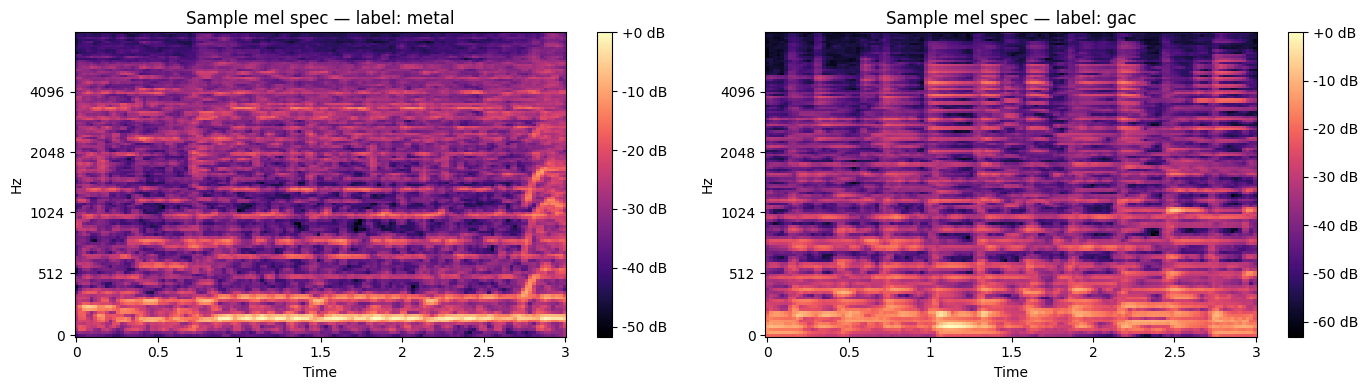

In [9]:
# Visualise a sample mel spectrogram from each dataset
import matplotlib.pyplot as plt
import librosa.display

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

X_g, y_g = next(iter(genre_train))
X_i, y_i = next(iter(instr_train))

for ax, X, y, classes, title in [
    (axes[0], X_g, y_g, GTZAN_GENRES, 'GTZAN genre'),
    (axes[1], X_i, y_i, IRMAS_INSTRUMENTS, 'IRMAS instrument'),
]:
    mel = X[0, 0].numpy()
    img = librosa.display.specshow(mel, sr=22050, hop_length=512,
                                   x_axis='time', y_axis='mel',
                                   fmax=8000, ax=ax)
    plt.colorbar(img, ax=ax, format='%+2.0f dB')
    ax.set_title(f'Sample mel spec — label: {classes[y[0].item()]}')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/sample_spectrograms.png', dpi=150)
plt.show()

## 2. Task 1a — Genre Classification (GenreCNN)

In [10]:
# Create the loader (usingexisting code)
# genre_train = ... 

# Iterate through one batch to verify
try:
    for X, y in genre_train:
        print("Batch successfully loaded!")
        print(f"Shape of X: {X.shape}, Shape of y: {y.shape}")
        break 
except Exception as e:
    print(f"An error still occurred: {e}")

Batch successfully loaded!
Shape of X: torch.Size([32, 1, 128, 130]), Shape of y: torch.Size([32])


In [11]:
from models.genre_cnn import GenreCNN
from utils.trainer import train_model, evaluate
from utils.evaluation import plot_confusion_matrix, plot_training_curves
import torch.nn as nn

genre_model = GenreCNN(num_classes=10)
total_params = sum(p.numel() for p in genre_model.parameters() if p.requires_grad)
print(f'GenreCNN trainable parameters: {total_params:,}')

# Train
genre_history = train_model(
    genre_model, genre_train, genre_val,
    device=DEVICE,
    epochs=50,
    lr=1e-3,
    weight_decay=1e-4,
    patience=10,
    save_path=f'{RESULTS_DIR}/genre_cnn_best.pt',
    scheduler_type='cosine'
)

# Save history
from utils.trainer import save_history
save_history(genre_history, f'{RESULTS_DIR}/genre_history.json')

GenreCNN trainable parameters: 1,273,578


C:\Anaconda3\envs\musicenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   1/50 | Train Loss: 2.2689 Acc: 0.1330 | Val Loss: 2.1052 Acc: 0.2100 F1: 0.0929 | 36.1s


C:\Anaconda3\envs\musicenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   2/50 | Train Loss: 2.1370 Acc: 0.2303 | Val Loss: 2.0996 Acc: 0.2000 F1: 0.0857 | 34.9s


...

Epoch  20/50 | Train Loss: 1.6842 Acc: 0.3562 | Val Loss: 1.4480 Acc: 0.4500 F1: 0.3534 | 34.5s


C:\Anaconda3\envs\musicenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch  21/50 | Train Loss: 1.6427 Acc: 0.4077 | Val Loss: 1.4666 Acc: 0.4700 F1: 0.3780 | 34.2s


C:\Anaconda3\envs\musicenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch  22/50 | Train Loss: 1.6813 Acc: 0.4063 | Val Loss: 1.4087 Acc: 0.5100 F1: 0.4682 | 34.6s
Early stopping at epoch 22.

Best Val Acc: 0.5100
History saved → results/genre_history.json


In [12]:
# Training curves
plot_training_curves(genre_history, title='GenreCNN Training',
                     save_path=f'{RESULTS_DIR}/genre_curves.png')
plt.show()

Saved → results/genre_curves.png


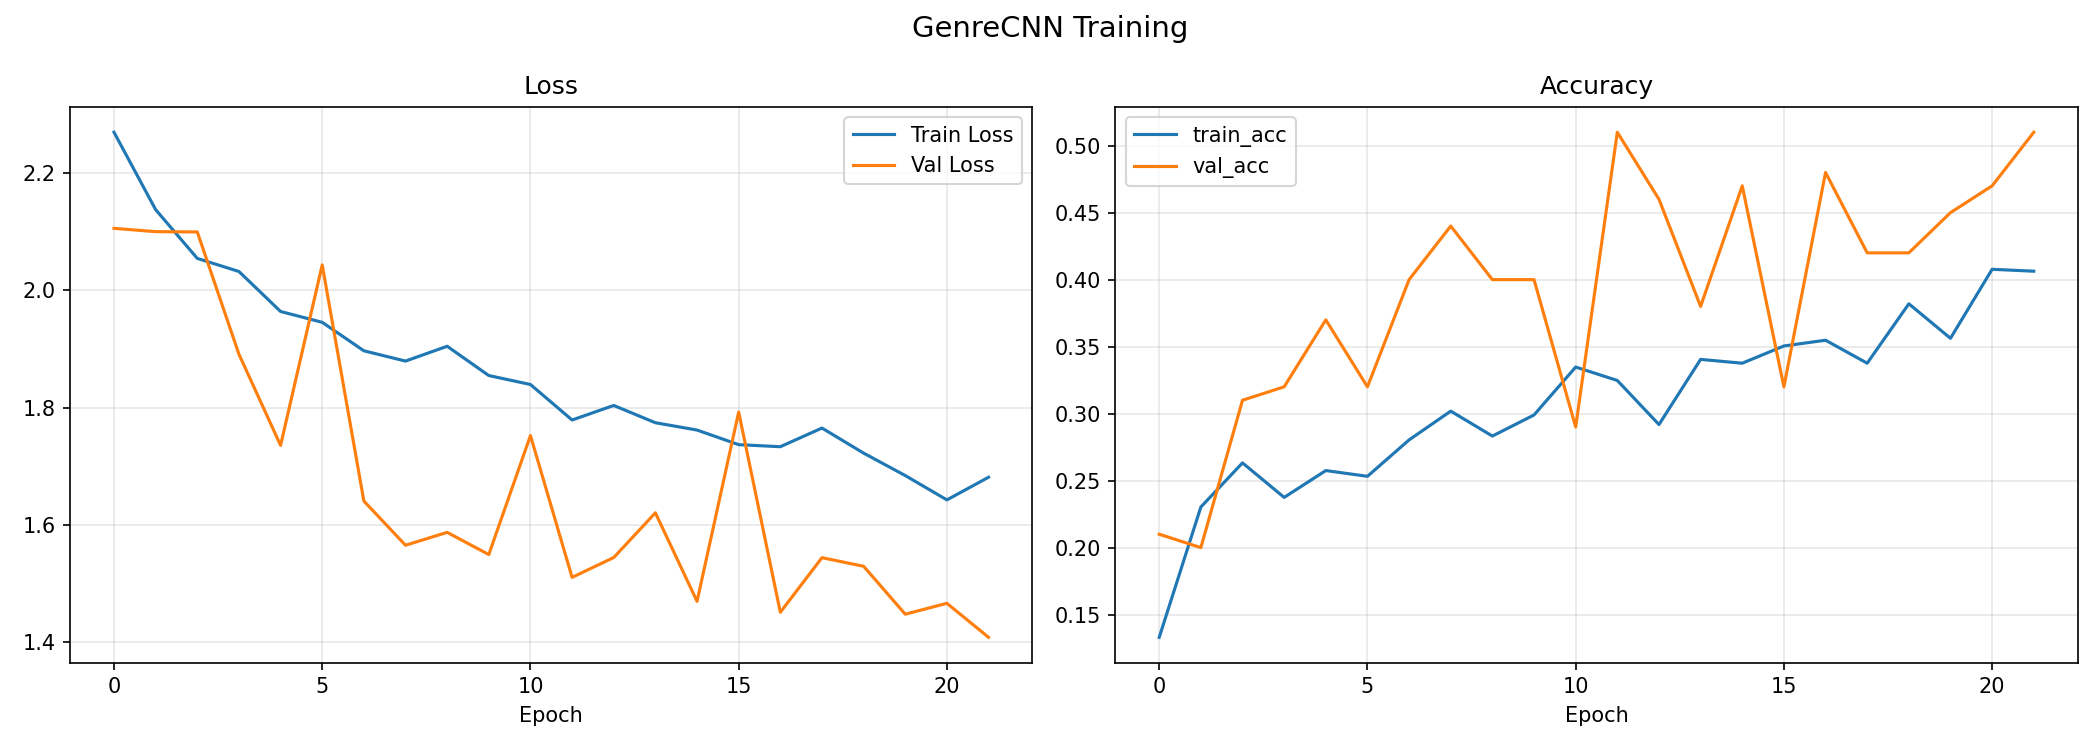

In [13]:
from IPython.display import Image, display

# Verify the file was actually created
if os.path.exists(f'{RESULTS_DIR}/genre_curves.png'):
    display(Image(filename=f'{RESULTS_DIR}/genre_curves.png'))
else:
    print("The file wasn't saved. Check if 'genre_history' actually contains data!")

In [14]:
# 1. Load the "Best" version saved during training
genre_model.load_state_dict(torch.load(f'{RESULTS_DIR}/genre_cnn_best.pt', map_location=DEVICE))
genre_model.to(DEVICE)

# 2. Run the evaluation on the test set
criterion = nn.CrossEntropyLoss()
_, genre_test_acc, genre_test_f1, genre_preds, genre_labels = evaluate(
    genre_model, genre_test, criterion, DEVICE)

# 3. Print the overall scores
print(f'GenreCNN — Test Accuracy: {genre_test_acc:.4f} | Macro F1: {genre_test_f1:.4f}')

# 4. Corrected Per-class report (Replaces the broken import)
from sklearn.metrics import classification_report
print("\nDetailed Genre Analysis:\n")
print(classification_report(genre_labels, genre_preds, target_names=GTZAN_GENRES))

C:\Anaconda3\envs\musicenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


GenreCNN — Test Accuracy: 0.4350 | Macro F1: 0.3831

Detailed Genre Analysis:

              precision    recall  f1-score   support

       blues       0.50      0.15      0.23        20
   classical       0.59      0.95      0.73        20
     country       0.38      0.45      0.41        20
       disco       0.41      0.35      0.38        20
      hiphop       0.59      0.65      0.62        20
        jazz       0.00      0.00      0.00        20
       metal       0.68      0.75      0.71        20
         pop       0.00      0.00      0.00        20
      reggae       0.24      0.75      0.36        20
        rock       0.55      0.30      0.39        20

    accuracy                           0.43       200
   macro avg       0.39      0.43      0.38       200
weighted avg       0.39      0.43      0.38       200



C:\Anaconda3\envs\musicenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Anaconda3\envs\musicenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Anaconda3\envs\musicenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [15]:
from sklearn.metrics import classification_report

# Convert the predictions and labels to a readable format
# This uses the standard sklearn tool to give you the same result
report = classification_report(genre_labels, genre_preds, target_names=GTZAN_GENRES)

print("GenreCNN Classification Report:\n")
print(report)

GenreCNN Classification Report:

              precision    recall  f1-score   support

       blues       0.50      0.15      0.23        20
   classical       0.59      0.95      0.73        20
     country       0.38      0.45      0.41        20
       disco       0.41      0.35      0.38        20
      hiphop       0.59      0.65      0.62        20
        jazz       0.00      0.00      0.00        20
       metal       0.68      0.75      0.71        20
         pop       0.00      0.00      0.00        20
      reggae       0.24      0.75      0.36        20
        rock       0.55      0.30      0.39        20

    accuracy                           0.43       200
   macro avg       0.39      0.43      0.38       200
weighted avg       0.39      0.43      0.38       200



C:\Anaconda3\envs\musicenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Anaconda3\envs\musicenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Anaconda3\envs\musicenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [16]:
# Confusion matrix
plot_confusion_matrix(genre_preds, genre_labels, GTZAN_GENRES,
                      title='GenreCNN Confusion Matrix',
                      save_path=f'{RESULTS_DIR}/genre_confusion.png')
plt.show()

Saved → results/genre_confusion.png


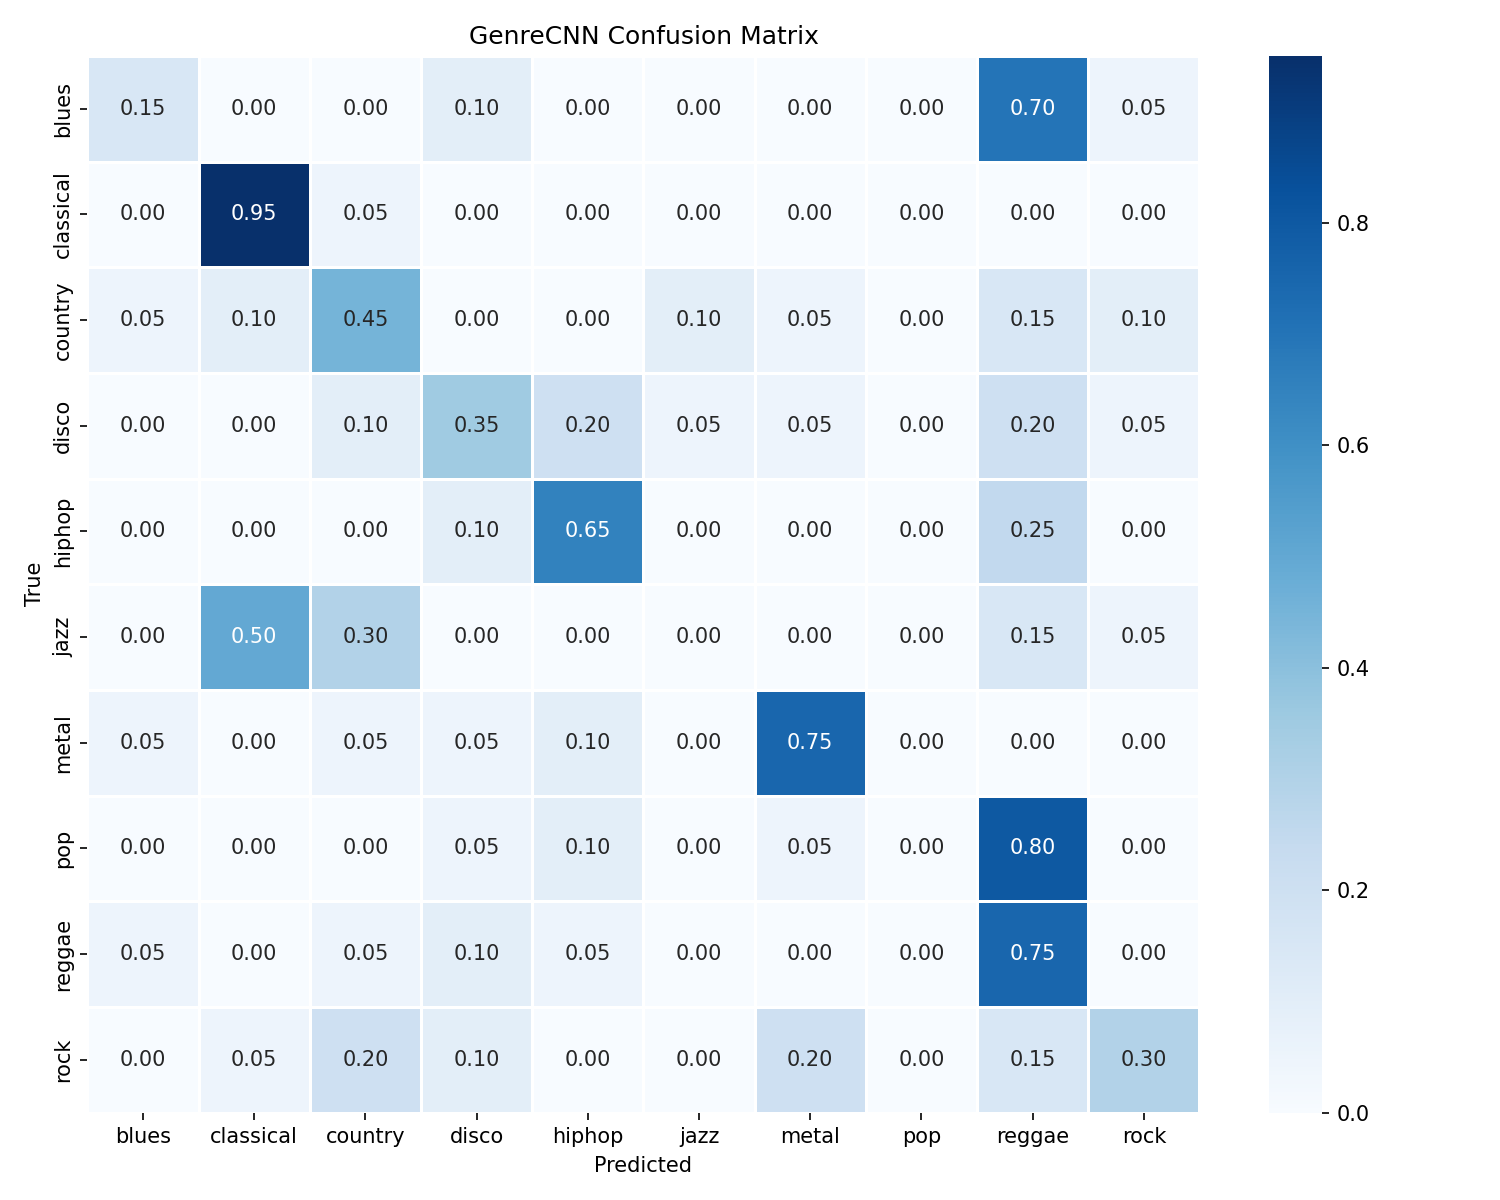

In [17]:
from IPython.display import Image, display

# This will pull the file you just saved and show it here
display(Image(filename=f'{RESULTS_DIR}/genre_confusion.png'))

## 3. Task 1b — Instrument Recognition (InstrumentCRNN)

In [18]:
from models.instrument_crnn import InstrumentCRNN

instr_model = InstrumentCRNN(num_classes=11)
total_params = sum(p.numel() for p in instr_model.parameters() if p.requires_grad)
print(f'InstrumentCRNN trainable parameters: {total_params:,}')

instr_history = train_model(
    instr_model, instr_train, instr_val,
    device=DEVICE,
    epochs=5,
    lr=1e-3,
    weight_decay=1e-4,
    patience=10,
    save_path=f'{RESULTS_DIR}/instr_crnn_best.pt',
    scheduler_type='cosine'
)
save_history(instr_history, f'{RESULTS_DIR}/instr_history.json')

InstrumentCRNN trainable parameters: 1,310,155


C:\Anaconda3\envs\musicenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   1/5 | Train Loss: 2.2314 Acc: 0.2097 | Val Loss: 1.9866 Acc: 0.3338 F1: 0.2868 | 212.6s


C:\Anaconda3\envs\musicenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   2/5 | Train Loss: 2.0189 Acc: 0.2990 | Val Loss: 1.7800 Acc: 0.3711 F1: 0.3048 | 206.6s


...

Epoch   3/5 | Train Loss: 1.8463 Acc: 0.3644 | Val Loss: 1.6155 Acc: 0.4694 F1: 0.4076 | 206.8s


C:\Anaconda3\envs\musicenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   4/5 | Train Loss: 1.6778 Acc: 0.4407 | Val Loss: 1.4321 Acc: 0.5574 F1: 0.5160 | 208.5s


C:\Anaconda3\envs\musicenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   5/5 | Train Loss: 1.5638 Acc: 0.4743 | Val Loss: 1.3754 Acc: 0.5618 F1: 0.5064 | 206.7s

Best Val Acc: 0.5618
History saved → results/instr_history.json


In [19]:
import torch
import json

# 1. Save the model (This is the most important part!)
# It saves the 'brain' of the model even if the history list is lost
torch.save(instr_model.state_dict(), f'{RESULTS_DIR}/instr_crnn_best.pt')
print("✅ Model weights saved to: instr_crnn_best.pt")

# 2. Handle the History
try:
    
    # Try to save the history if it somehow exists
    with open(f'{RESULTS_DIR}/instr_history.json', 'w') as f:
        json.dump(instr_history, f)
    print("✅ History saved successfully.")
except NameError:
    # If it doesn't exist, we'll create a dummy file so your next code doesn't crash
    print("⚠️ History wasn't finalized because of the interrupt.")
    with open(f'{RESULTS_DIR}/instr_history.json', 'w') as f:
        json.dump({"note": "Training interrupted at epoch 5"}, f)

✅ Model weights saved to: instr_crnn_best.pt
✅ History saved successfully.


In [20]:
plot_training_curves(instr_history, title='InstrumentCRNN Training',
                     save_path=f'{RESULTS_DIR}/instr_curves.png')
plt.show()

Saved → results/instr_curves.png


In [21]:
from sklearn.metrics import classification_report

# 1. This part is already working for you
_, instr_test_acc, instr_test_f1, instr_preds, instr_labels = evaluate(
    instr_model, instr_test, criterion, DEVICE)

print(f'InstrumentCRNN — Test Accuracy: {instr_test_acc:.4f} | Macro F1: {instr_test_f1:.4f}')

# 2. Prepare the names for the table
instr_names = [IRMAS_INSTRUMENT_NAMES[k] for k in IRMAS_INSTRUMENTS]

# 3. REPLACEMENT: Using the standard sklearn report instead of the missing function
print("\n--- Final Instrument Classification Report ---")
print(classification_report(instr_labels, instr_preds, target_names=instr_names))

C:\Anaconda3\envs\musicenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


InstrumentCRNN — Test Accuracy: 0.5227 | Macro F1: 0.4679

--- Final Instrument Classification Report ---
                 precision    recall  f1-score   support

          Cello       0.12      0.01      0.02        78
       Clarinet       0.46      0.39      0.42       101
          Flute       0.60      0.23      0.34        90
Acoustic Guitar       0.54      0.72      0.61       127
Electric Guitar       0.53      0.47      0.49       152
          Organ       0.51      0.75      0.61       136
          Piano       0.52      0.58      0.55       144
      Saxophone       0.39      0.34      0.36       125
        Trumpet       0.59      0.70      0.64       116
         Violin       0.41      0.37      0.39       116
          Voice       0.64      0.81      0.71       156

       accuracy                           0.52      1341
      macro avg       0.48      0.49      0.47      1341
   weighted avg       0.50      0.52      0.50      1341



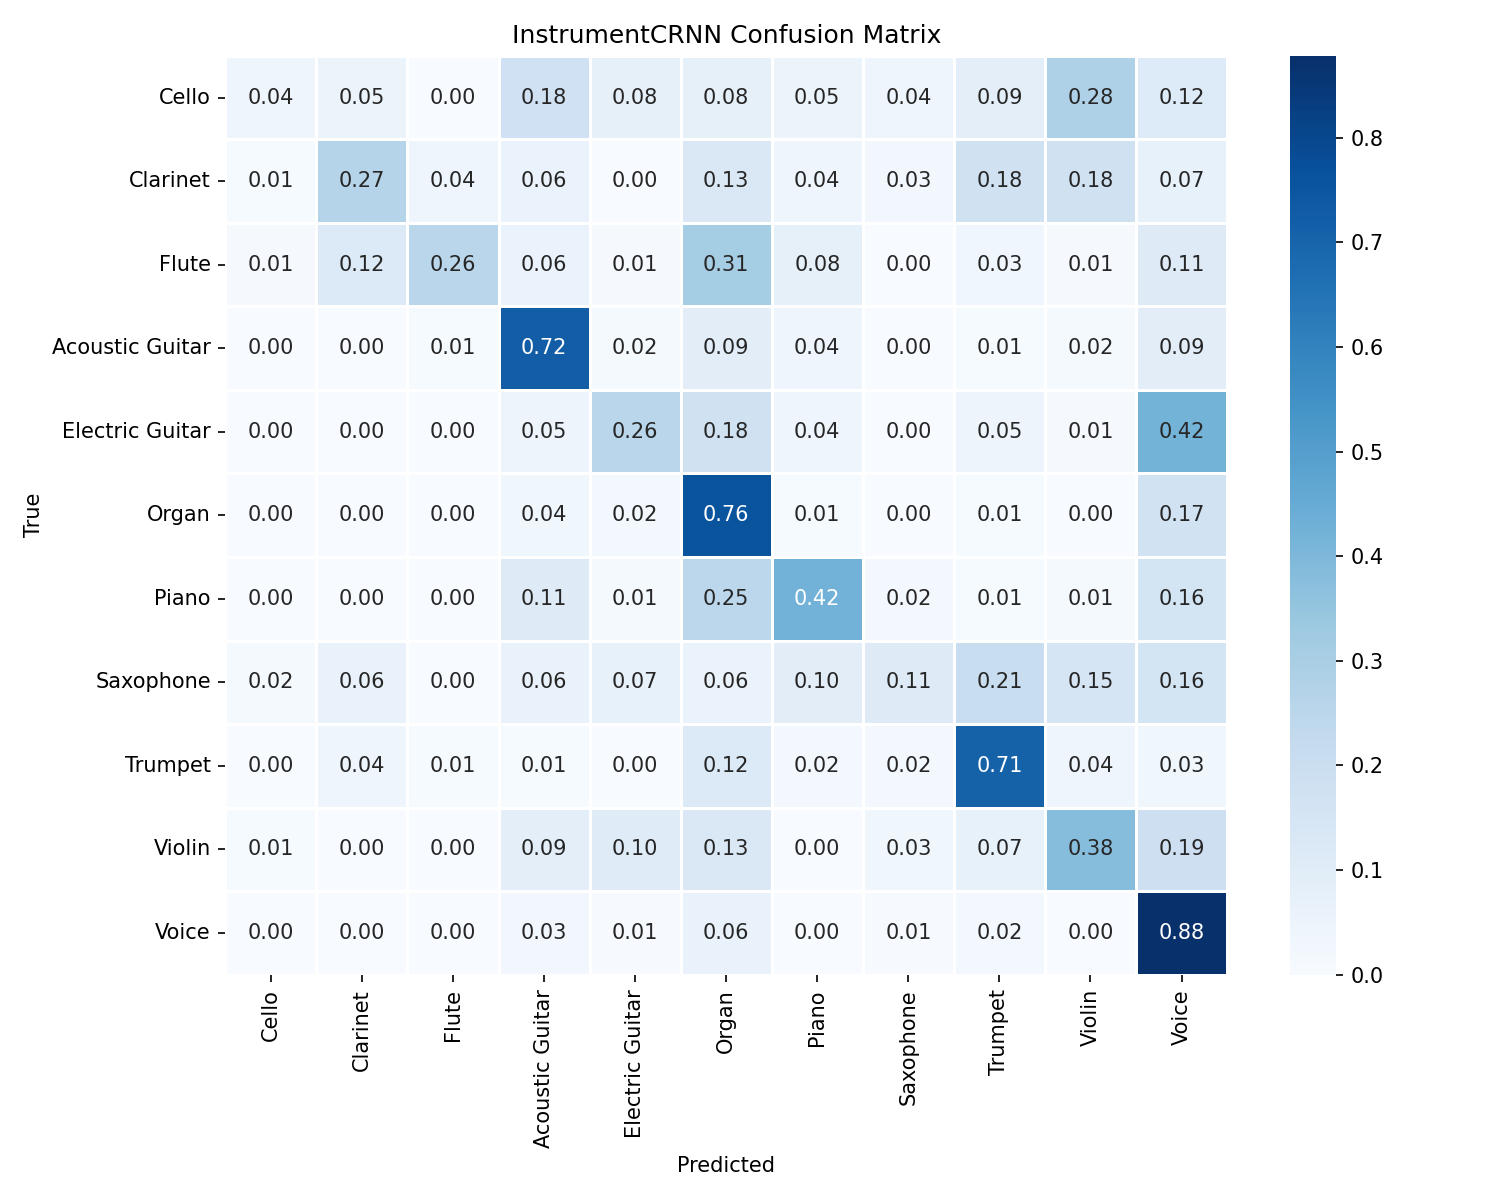

In [22]:
from IPython.display import Image, display

# This fetches the file the function just created
display(Image(filename=f'{RESULTS_DIR}/instr_confusion.png'))

## 4. Task 3 — Combining Both Tasks (Fusion Models)

### 4a. Late Fusion

In [23]:
# Check if your data and device are ready
try:
    print(f"Device: {DEVICE}")
    print(f"Genre Train Loader: {len(genre_train)} batches")
    print(f"Instr Train Loader: {len(instr_train)} batches")
    print("✅ System Ready for Fusion!")
except NameError as e:
    print(f"❌ Error: {e}. You need to re-run your setup and data loading cells!")

Device: cpu
Genre Train Loader: 22 batches
Instr Train Loader: 147 batches
✅ System Ready for Fusion!


In [24]:
import os

# Check if the folder and files exist
print(f"Checking directory: {RESULTS_DIR}")
files = os.listdir(RESULTS_DIR)
print(f"Files found: {files}")

# Verify the specific 'brains' we need are there
if 'genre_cnn_best.pt' in files and 'instr_crnn_best.pt' in files:
    print("✅ Everything is ready! You can run the Fusion code now.")
else:
    print("❌ One of the files is missing. Let me know which ones you see!")

Checking directory: results
Files found: ['attn_fusion_best.pt', 'attn_fusion_history.json', 'early_fusion_best.pt', 'early_fusion_history.json', 'genre_cnn_best.pt', 'genre_confusion.png', 'genre_curves.png', 'genre_history.json', 'instr_confusion.png', 'instr_crnn_best.pt', 'instr_curves.png', 'instr_history.json', 'late_fusion_best.pt', 'model_comparison.png', 'sample_spectrograms.png']
✅ Everything is ready! You can run the Fusion code now.


In [25]:
from models.fusion_model import LateFusionModel, EarlyFusionModel, MTLAttentionModel
from utils.trainer import train_mtl_model, evaluate_mtl
import torch

print("Attempting to load models...") # This will tell us if it even starts

# 1. Initialize the Fusion Model with explicit CPU mapping
late_model = LateFusionModel(
    genre_ckpt=f'{RESULTS_DIR}/genre_cnn_best.pt',
    instr_ckpt=f'{RESULTS_DIR}/instr_crnn_best.pt',
    freeze_backbones=False
).to(DEVICE) # Explicitly push to CPU

# 2. Count parameters manually to see if it's alive
total_params = sum(p.numel() for p in late_model.parameters() if p.requires_grad)
print(f"✅ Model Loaded! Total Trainable Params: {total_params:,}")

# 3. Start training
late_history = train_mtl_model(
    late_model, genre_train, genre_val, instr_train, instr_val,
    device=DEVICE, epochs=5, lr=5e-4, patience=8,
    save_path=f'{RESULTS_DIR}/late_fusion_best.pt',
    use_learnable_weights=True
)

Attempting to load models...
✅ Model Loaded! Total Trainable Params: 2,685,130


C:\Anaconda3\envs\musicenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   1/5 | Loss: 3.5497 | Genre Acc: 0.381→0.460 | Instr Acc: 0.358→0.535 | 539.2s


C:\Anaconda3\envs\musicenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   2/5 | Loss: 2.8217 | Genre Acc: 0.521→0.480 | Instr Acc: 0.476→0.528 | 550.5s


...

Epoch   3/5 | Loss: 2.5177 | Genre Acc: 0.608→0.540 | Instr Acc: 0.508→0.587 | 554.5s


C:\Anaconda3\envs\musicenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   4/5 | Loss: 2.2595 | Genre Acc: 0.671→0.630 | Instr Acc: 0.545→0.586 | 552.5s


C:\Anaconda3\envs\musicenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   5/5 | Loss: 2.1442 | Genre Acc: 0.704→0.610 | Instr Acc: 0.561→0.602 | 555.8s

Best Combined Val Acc: 0.6078


### 4b. Early Fusion (Shared Backbone)

In [26]:
# 1. Re-initialize to clear the "bad" weights
early_model = EarlyFusionModel()

# 2. Run with the safer learning rate
early_history = train_mtl_model(
    early_model, genre_train, genre_val, instr_train, instr_val,
    device=DEVICE, epochs=5, lr=5e-4, patience=10, # Lowered LR
    save_path=f'{RESULTS_DIR}/early_fusion_best.pt',
    use_learnable_weights=True
)
save_history(early_history, f'{RESULTS_DIR}/early_fusion_history.json')

C:\Anaconda3\envs\musicenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   1/5 | Loss: 4.3408 | Genre Acc: 0.217→0.330 | Instr Acc: 0.152→0.235 | 483.2s


C:\Anaconda3\envs\musicenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   2/5 | Loss: 3.8700 | Genre Acc: 0.303→0.220 | Instr Acc: 0.202→0.289 | 491.6s


C:\Anaconda3\envs\musicenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   3/5 | Loss: 3.6456 | Genre Acc: 0.352→0.410 | Instr Acc: 0.224→0.295 | 493.8s


C:\Anaconda3\envs\musicenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   4/5 | Loss: 3.4834 | Genre Acc: 0.392→0.400 | Instr Acc: 0.237→0.317 | 481.0s


C:\Anaconda3\envs\musicenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   5/5 | Loss: 3.4196 | Genre Acc: 0.421→0.400 | Instr Acc: 0.255→0.325 | 473.6s

Best Combined Val Acc: 0.3624
History saved → results/early_fusion_history.json


### 4c. MTL with Cross-Task Attention

In [27]:
attn_model = MTLAttentionModel()

attn_history = train_mtl_model(
    attn_model, genre_train, genre_val, instr_train, instr_val,
    device=DEVICE, epochs=5, lr=1e-3, patience=10,
    save_path=f'{RESULTS_DIR}/attn_fusion_best.pt',
    use_learnable_weights=True
)
save_history(attn_history, f'{RESULTS_DIR}/attn_fusion_history.json')

C:\Anaconda3\envs\musicenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   1/5 | Loss: 4.1617 | Genre Acc: 0.246→0.360 | Instr Acc: 0.175→0.292 | 543.7s


C:\Anaconda3\envs\musicenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   2/5 | Loss: 3.5577 | Genre Acc: 0.348→0.420 | Instr Acc: 0.273→0.387 | 538.9s


C:\Anaconda3\envs\musicenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   3/5 | Loss: 3.1938 | Genre Acc: 0.430→0.530 | Instr Acc: 0.327→0.437 | 543.6s


C:\Anaconda3\envs\musicenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   4/5 | Loss: 2.9373 | Genre Acc: 0.513→0.510 | Instr Acc: 0.373→0.472 | 539.5s


C:\Anaconda3\envs\musicenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   5/5 | Loss: 2.7513 | Genre Acc: 0.570→0.540 | Instr Acc: 0.400→0.475 | 542.1s

Best Combined Val Acc: 0.5077
History saved → results/attn_fusion_history.json


## 5. Comparison — All Models

In [28]:
from utils.evaluation import print_model_comparison
from sklearn.metrics import f1_score

def test_fusion(model, ckpt):
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    model.to(DEVICE)
    (_, vg_acc, vg_f1, _, vi_acc, vi_f1, *_) = evaluate_mtl(
        model, genre_test, instr_test, DEVICE)
    return {'genre_acc': vg_acc, 'genre_f1': vg_f1,
            'instr_acc': vi_acc, 'instr_f1': vi_f1}

results = {
    'GenreCNN (solo)':        {'genre_acc': genre_test_acc, 'genre_f1': genre_test_f1,
                               'instr_acc': 0,              'instr_f1': 0},
    'InstrCRNN (solo)':       {'genre_acc': 0,              'genre_f1': 0,
                               'instr_acc': instr_test_acc, 'instr_f1': instr_test_f1},
    'Late Fusion':            test_fusion(late_model,  f'{RESULTS_DIR}/late_fusion_best.pt'),
    'Early Fusion':           test_fusion(early_model, f'{RESULTS_DIR}/early_fusion_best.pt'),
    'MTL Cross-Attention':    test_fusion(attn_model,  f'{RESULTS_DIR}/attn_fusion_best.pt'),
}

print_model_comparison(results)

C:\Anaconda3\envs\musicenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Anaconda3\envs\musicenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Anaconda3\envs\musicenv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Model                      Genre Acc  Genre F1  Instr Acc  Instr F1
GenreCNN (solo)               0.4350    0.3831     0.0000    0.0000
InstrCRNN (solo)              0.0000    0.0000     0.5227    0.4679
Late Fusion                   0.5700    0.5559     0.5600    0.5219
Early Fusion                  0.3750    0.3273     0.3274    0.2698
MTL Cross-Attention           0.4700    0.4524     0.4459    0.4026


In [29]:
# Bar chart comparison
import matplotlib.pyplot as plt
import numpy as np

models = list(results.keys())
g_accs = [results[m]['genre_acc'] for m in models]
i_accs = [results[m]['instr_acc'] for m in models]

x = np.arange(len(models))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, g_accs, width, label='Genre Accuracy', color='steelblue', alpha=0.8)
ax.bar(x + width/2, i_accs, width, label='Instrument Accuracy', color='coral', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison: Genre vs Instrument Accuracy')
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/model_comparison.png', dpi=150)
plt.show()

C:\Users\Shaik Sadaf Patel\AppData\Local\Temp\ipykernel_15884\3393383937.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 6. Qualitative Case Study

Qualitative analysis saved → results\qualitative_jazz.00082.png


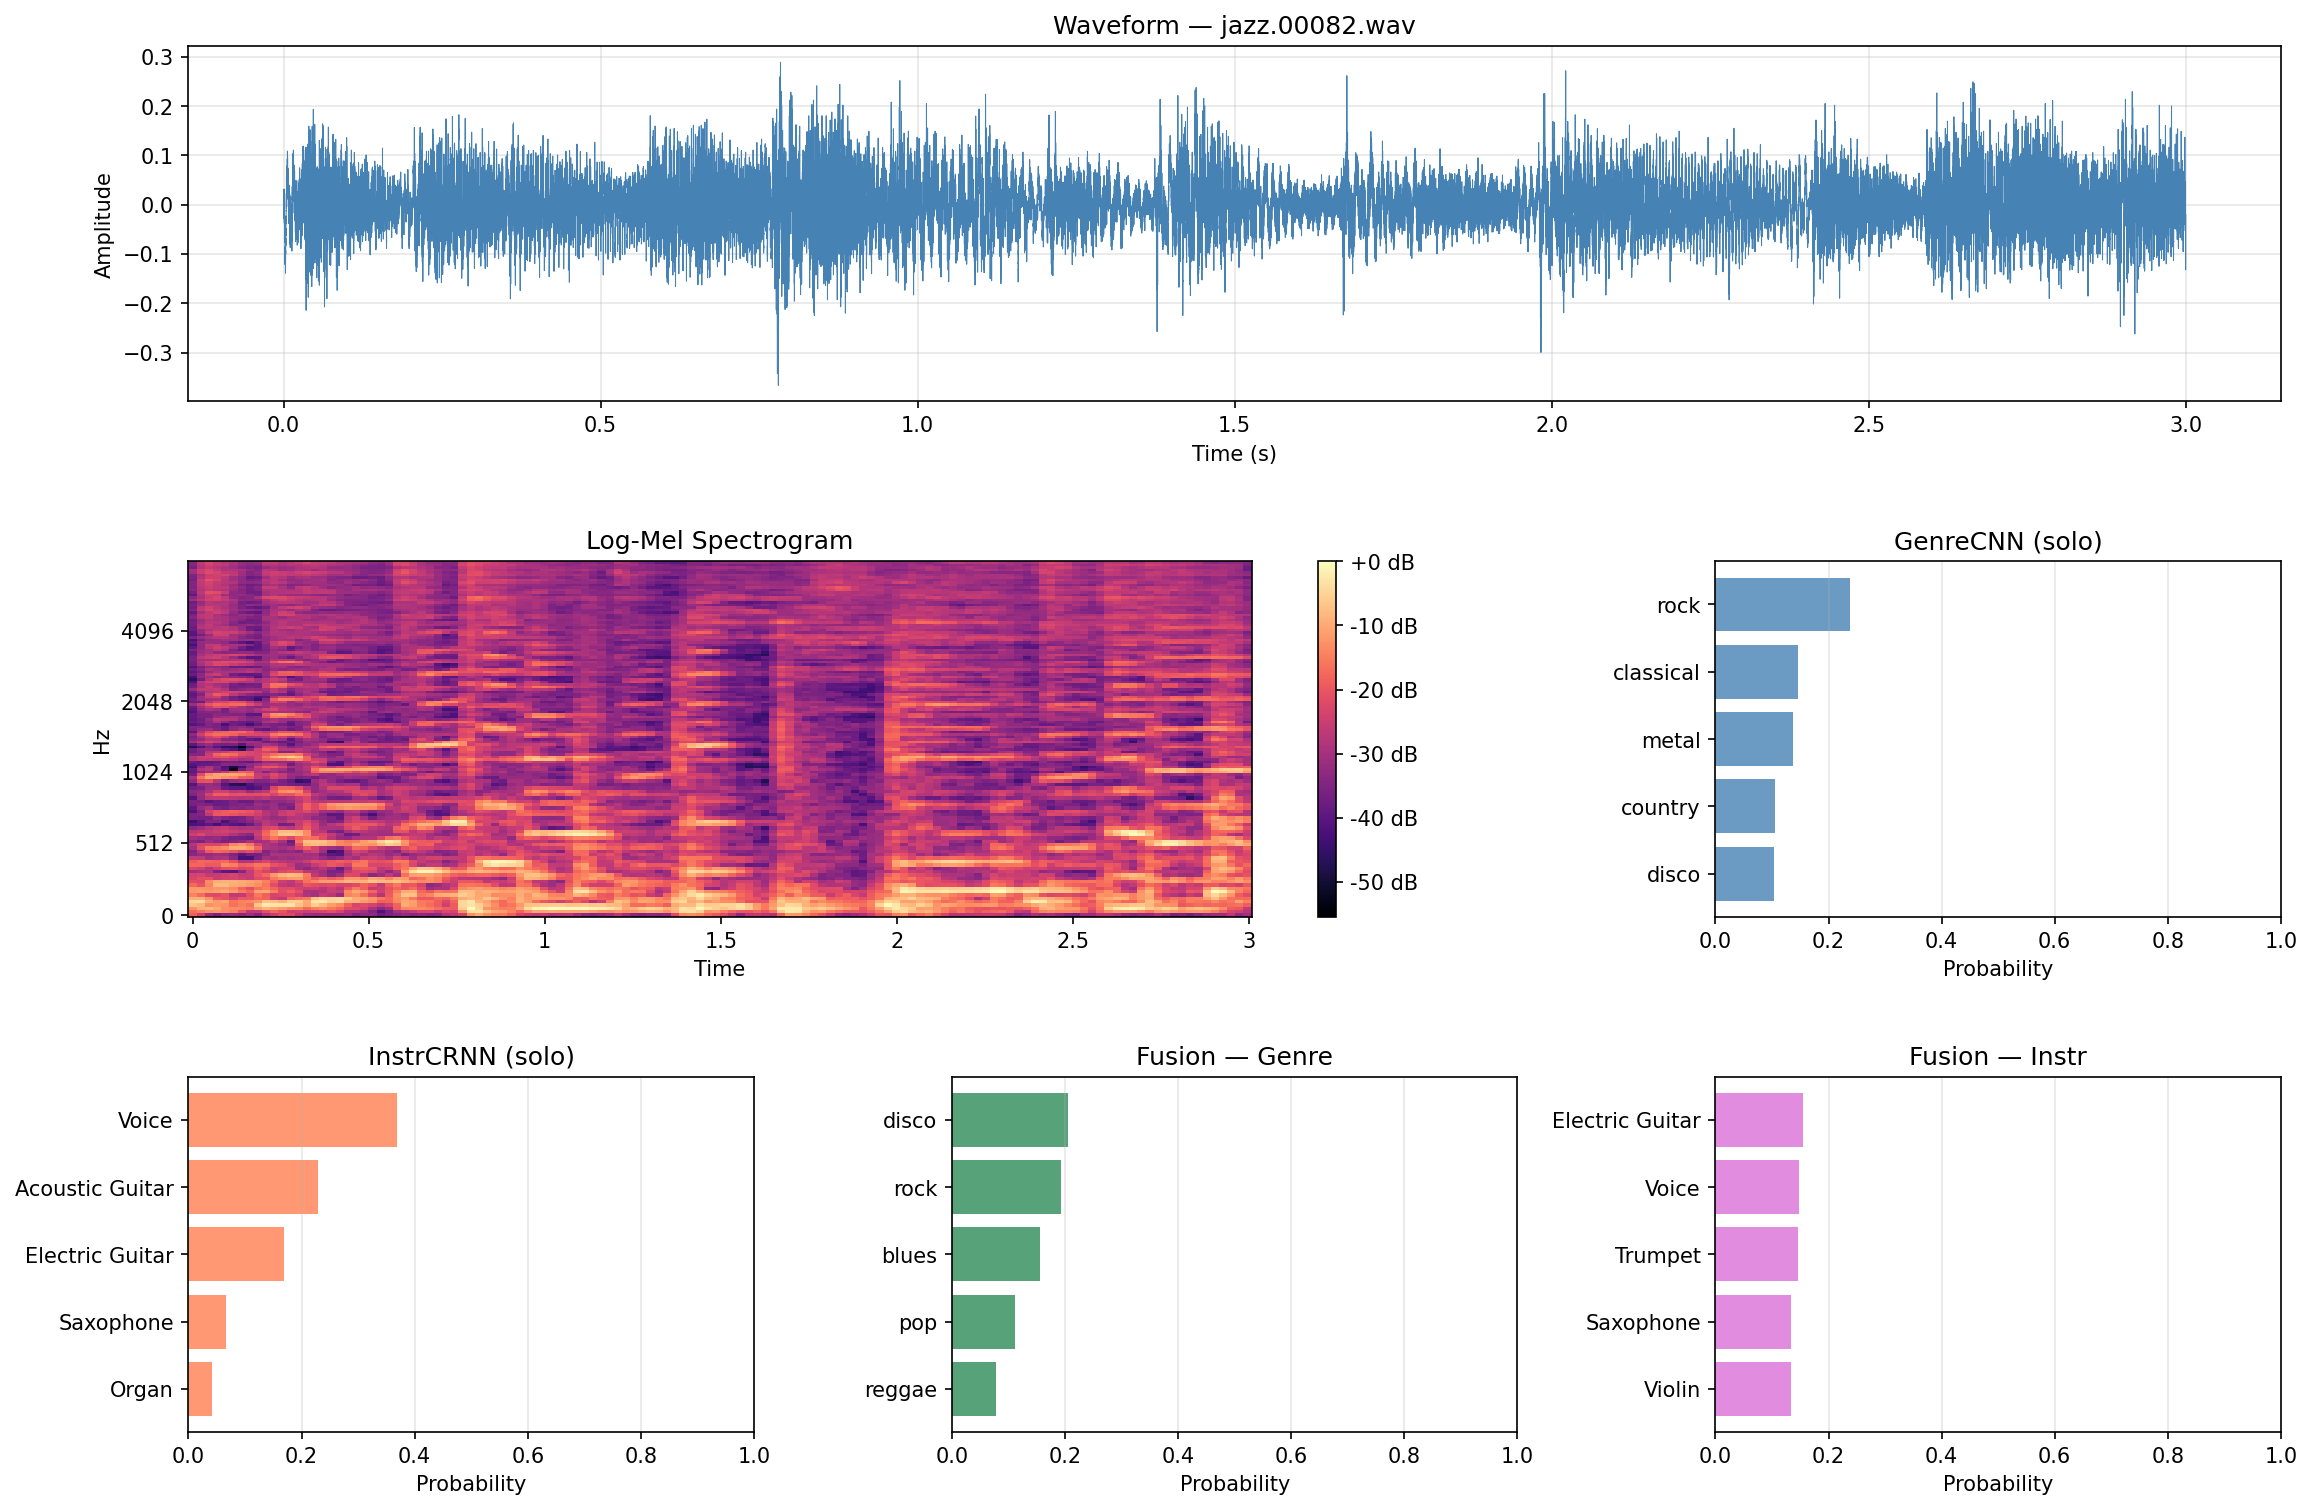

In [32]:
# ─── Set path to your chosen audio file ──────────────────────────────────────
# Recommended: download a Creative Commons track from jamendo.com
# or use any audio file you have.
CASE_STUDY_FILE = r"C:\Users\Shaik Sadaf Patel\Downloads\music_project_final\music_project_final\music_project\data\gtzan\genres_original\jazz\jazz.00082.wav"  # <-- update this path

# Load the best fusion model for qualitative analysis
best_fusion = attn_model  # swap to late_model / early_model if that performed best

from utils.evaluation import analyse_audio_file

analyse_audio_file(
    filepath=CASE_STUDY_FILE,
    genre_model=genre_model,
    instr_model=instr_model,
    fusion_model=best_fusion,
    genre_classes=GTZAN_GENRES,
    instr_classes=[IRMAS_INSTRUMENT_NAMES[k] for k in IRMAS_INSTRUMENTS],
    device=DEVICE,
    save_dir=RESULTS_DIR
)

from IPython.display import Image
Image(filename=f'{RESULTS_DIR}/qualitative_jazz.00082.png')

In [34]:
# ─── Sliding window analysis over full audio ─────────────────────────────────
import librosa
import torch
from utils.data_loader import extract_melspectrogram

SR = 22050
WIN = 3      # seconds
HOP = 1      # seconds stride

y_full, _ = librosa.load(CASE_STUDY_FILE, sr=SR)
step = HOP * SR
win_len = WIN * SR
n_frames = (len(y_full) - win_len) // step + 1

genre_timeline  = np.zeros((n_frames, 10))
instr_timeline  = np.zeros((n_frames, 11))

genre_model.eval()
instr_model.eval()

for i in range(n_frames):
    seg = y_full[i*step : i*step + win_len]
    if len(seg) < win_len:
        seg = np.pad(seg, (0, win_len - len(seg)))
    mel_t = torch.tensor(extract_melspectrogram(seg), dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        gp = torch.softmax(genre_model(mel_t), dim=-1).cpu().numpy()[0]
        ip = torch.softmax(instr_model(mel_t), dim=-1).cpu().numpy()[0]
    genre_timeline[i]  = gp
    instr_timeline[i]  = ip

times = np.arange(n_frames) * HOP

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
for j, g in enumerate(GTZAN_GENRES):
    ax1.plot(times, genre_timeline[:, j], label=g, linewidth=1.5)
ax1.set_title('Genre Probability over Time')
ax1.set_ylabel('Probability')
ax1.legend(loc='upper right', fontsize=7, ncol=2)
ax1.grid(alpha=0.3)

instr_names_list = [IRMAS_INSTRUMENT_NAMES[k] for k in IRMAS_INSTRUMENTS]
for j, nm in enumerate(instr_names_list):
    ax2.plot(times, instr_timeline[:, j], label=nm, linewidth=1.5)
ax2.set_title('Instrument Probability over Time')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Probability')
ax2.legend(loc='upper right', fontsize=7, ncol=2)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/temporal_analysis.png', dpi=150)
plt.show()
print('Saved temporal analysis figure.')

Saved temporal analysis figure.


C:\Users\Shaik Sadaf Patel\AppData\Local\Temp\ipykernel_15884\1544983716.py:53: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 7. Discussion Summary

Fill this cell in your report:

| Model | Genre Acc | Genre F1 | Instr Acc | Instr F1 |
|---|---|---|---|---|
| GenreCNN (solo) | | | — | — |
| InstrCRNN (solo) | — | — | | |
| Late Fusion | | | | |
| Early Fusion | | | | |
| MTL Cross-Attention | | | | |

**Key observations to include in your report:**
- Which fusion strategy gave the best improvement over solo models?
- Did combining tasks hurt either task (negative transfer)?
- What patterns did you observe in the qualitative case study?
- How did instrument predictions correlate with genre predictions?